# load code

In [2]:
pathtosrc = "."; # path to where ATIsimPL is located

In [3]:
include(pathtosrc*"/src/PLIntegration1D.jl");
using .PLIntegration1D

In [4]:
include(pathtosrc*"/src/ContourIntersection.jl");
using .ContourIntersection

In [5]:
include(pathtosrc*"/src/critical-points.jl")
include(pathtosrc*"/src/saddle-point-method.jl");

In [4]:
using CairoMakie

# setup

(This is what you need to adjust according to your definitions of the fields, the momentum, target etc.)

In [15]:
include(pathtosrc*"/AnnesATI.jl")

## fixed parameters

In [16]:
const λ = 800 # nm
const Intensity0 = 4e14 # W/cm2
const Ip = IpAU(13.5984) # Hydrogen gas target

const ω = 2 * π * LAU * c / λ
const TC = 2*π/ω;

## field configurations

In [17]:
### convenience constructor for a co-linear two-colour field with mixing angle θ and phase shift ϕ
beam_mx(θ::Number, ϕ::Number) = BeamBETC(Intensity1 = (cos(θ))^2 * Intensity0, 
    Intensity2 = (sin(θ))^2 * Intensity0,
    lambda = λ, r=1,s=2, epsilon=0.,
    phi = ϕ)

beam_mx (generic function with 1 method)

In [18]:
beam_TWOB = beam_mx(π/4, +π/2) # the tunnelling without barrier scenario from our paper

BeamTC(0.07559289460184546, 0.07559289460184544, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 1.5707963267948966)

In [20]:
beam_mono = BeamMono(Intensity = Intensity0, lambda=λ, epsilon=0., phi = 0.) # a simple monochromatic field

BeamMono(0.10690449676496976, 0.056939529014612654, 0.0, 0.0)

### plot the field shape over time

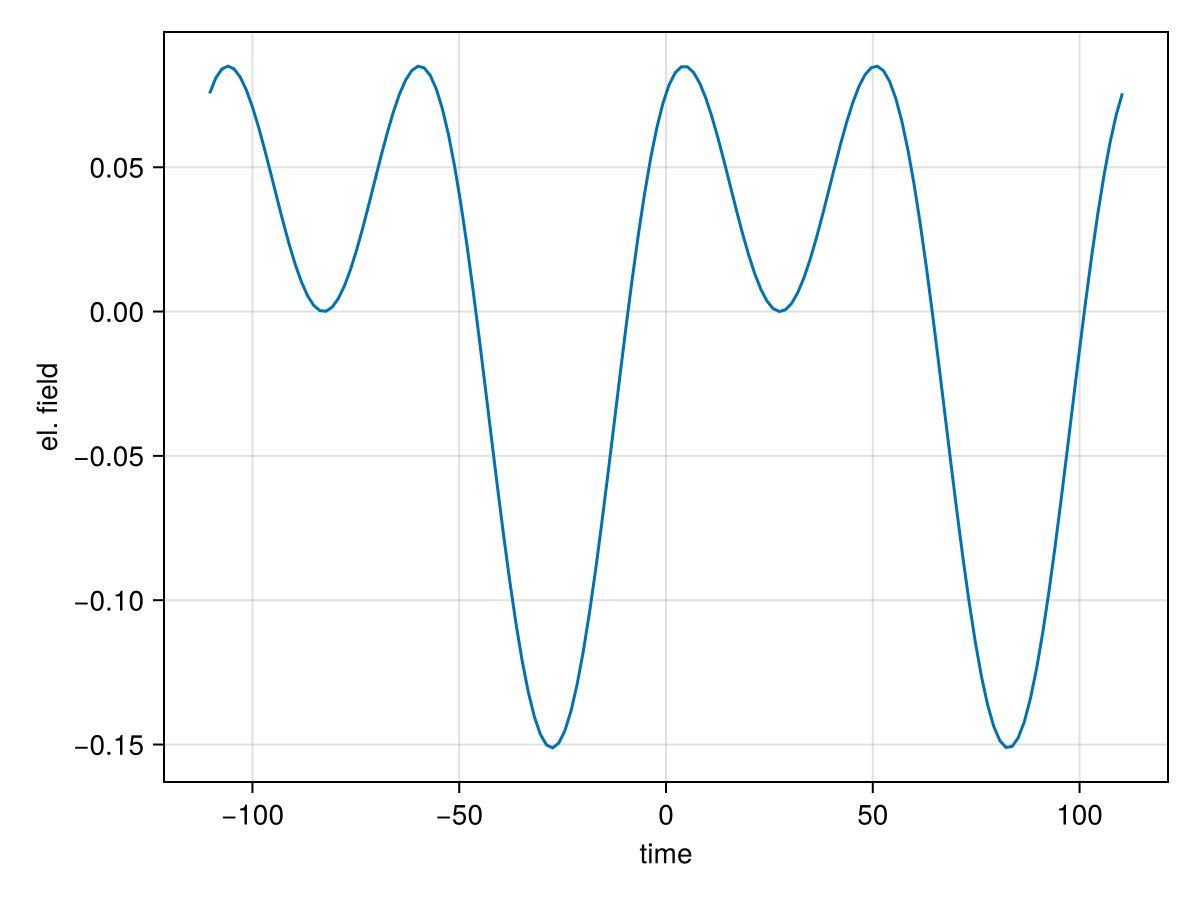

In [62]:
let
    beam = beam_TWOB

    Nt = 150
    times = range(-TC, stop = TC, length = Nt)    
    
    efield = [E(beam)(t)[1] for t in times] # only the [1] component (x)

    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time",
        ylabel = "el. field",
    ) 
    
    lines!(ax, times, efield)

    f
end

## momentum

It makes sense to look at momenta up to $2 U_\mathrm{pond}$.

In [27]:
Upond(beam_TWOB)

0.5507876985417118

## finding saddle points and telling whether they are relevant

In [34]:
let
    beam = beam_mono
    momentum = [0.,0.] # wants to be a Vector
    
    ### define your phase functions, as functions of 't' only. In our case that's the semi-classical action S
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)

    ### get saddle points within a defined time window
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    saddles = filter(ts -> real(tmin) < real(ts) < real(tmax), 
        filter(ts->imag(ts)>0, find_saddles_sobol(S_drv, tmin, tmax, 300))
        )
#     display(saddles)
    
    for ts in saddles
        @show ts
        relevant = is_contributing(ts, S, tmin, tmax)
        @show relevant
    end
    
end

ts = 27.59 + 8.96im
relevant = true
ts = 82.76 + 8.96im
relevant = true


# trajectories

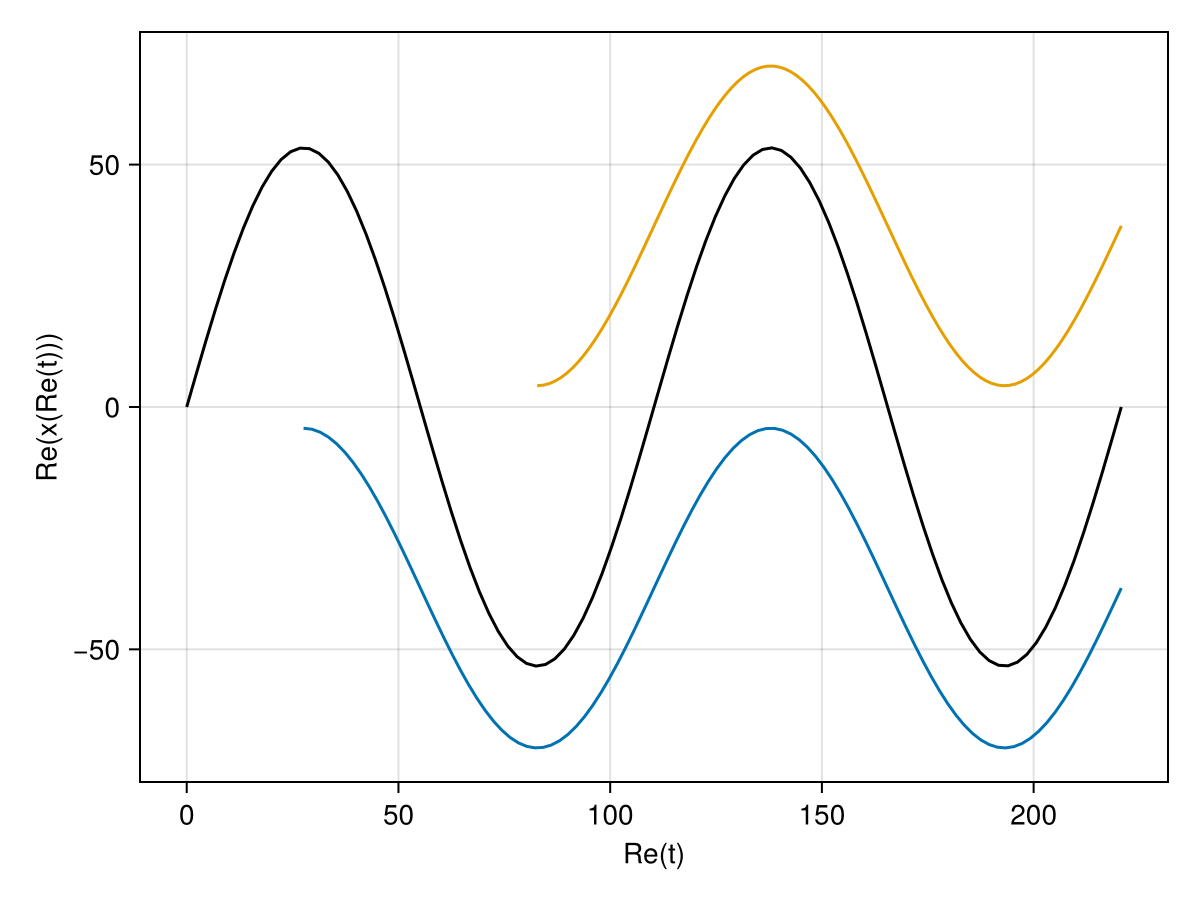

In [61]:
let
    beam = beam_mono
    momentum = [0.,0.] # wants to be a Vector
    
    ### define your phase functions, as functions of 't' only. 
    ### In our case that's the semi-classical action S
    S(t) = action(beam, momentum, t)
    S_drv(t) = action_drv(beam, momentum, t)

    ### get saddle points within a defined time window
    tmin = 0. + 0im # min(t real) + 0.
    tmax = TC + TC/2*im # min(t real) + max(t imag)
    
    saddles = filter(ts -> real(tmin) < real(ts) < real(tmax), 
        filter(ts->imag(ts)>0, find_saddles_sobol(S_drv, tmin, tmax, 300))
        )
    
    f = Figure()    
    ax = Axis(f[1, 1], xlabel = "Re(t)",ylabel = "Re(x(Re(t)))") 
    
    ### plot the electric field
    times = range(0., stop = 2*TCycle(beam), length = 100)    
    efield = [E(beam)(t)[1] for t in times] # only the [1] component (x)    
    lines!(ax, times, efield.*0.5e3, color = :black)
        
    
    for ts in saddles
#         relevant = is_contributing(ts, S, tmin, tmax)
#         @show relevant
        
        real_times = range(real(ts), stop = 2*TCycle(beam), length = 100)
        positions = [ (momentum .+ integrated_vector_potential(beam)(ts, t))[1] 
            #[1] because we only care about the x component here
            for t in real_times ]
        
        lines!(ax, real_times, real.([p[1] for p in positions]), linestyle = :solid)
    end

    f    
end